<div style="background:linear-gradient(120deg,#143642,#0f766e 58%,#2f6f73);padding:24px 28px;border-radius:10px;color:white">
  <h1 style="margin:0;font-size:30px">全项目图像与图表生成溯源 Notebook</h1>
  <p style="margin:10px 0 0;font-size:15px;line-height:1.55">
  面向报告、PPT、论文、街景、断面图和深度学习结果，逐张追踪 image → 生成代码 → 输入数据 → 重跑命令。
  </p>
</div>

## 说明

本 Notebook 不再只解释 PPT 中少数图表，而是以 `image_provenance_manifest.csv` 为主线，对项目内所有主要图片资产做溯源。  
其中：

- `exact_known / exact_script_hit`：脚本中有固定输出名或静态扫描命中；
- `directory_match`：批量目录由固定生成脚本维护，例如街道断面图、街景标注图；
- `raw_acquired`：不是绘图脚本生成，而是街景采集/下载得到的原始影像；
- `directory_inferred`：历史脚本较多，按目录、命名和脚本命中综合判断。

远程GPU、SSH、API相关脚本只作为来源路径记录；Notebook 默认不执行这些命令，也不会修改 PPT/DOCX。


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown, Image

ROOT = Path.cwd()
while not (ROOT / "projects" / "15min-urban-accessibility").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
PROJECT = ROOT / "projects" / "15min-urban-accessibility"
OUT = PROJECT / "notebook_outputs"
MANIFEST = OUT / "image_provenance_manifest.csv"
SUMMARY = OUT / "image_provenance_group_summary.csv"
HITS = OUT / "image_provenance_script_hits.csv"
CONTACT = OUT / "image_provenance_contact_sheet.png"

manifest = pd.read_csv(MANIFEST, encoding="utf-8-sig")
summary = pd.read_csv(SUMMARY, encoding="utf-8-sig")
hits = pd.read_csv(HITS, encoding="utf-8-sig") if HITS.exists() else pd.DataFrame()

print("工作区:", ROOT)
print("图片总数:", len(manifest))
print("类别数:", manifest["category"].nunique())
display(summary)


工作区: E:\xicha gis 智能定位
图片总数: 5043
类别数: 33


,category,image_count,top_confidence,primary_generating_code,example_image
0,SCI街道断面图,624,directory_match:624,projects/15min-urban-accessibility/v2_real_dat...,projects/15min-urban-accessibility/v2_real_dat...
1,百度街景采集图,598,raw_acquired:586; raw_acquired+exact_hit:12,projects/15min-urban-accessibility/data/street...,streetview-analysis/baidu_streetview/segmentat...
2,街景YOLO中文标注图,588,directory_match:588,streetview-analysis/gpu_scripts/render_only_v2...,streetview-analysis/annotated_streetview/113.8...
3,街景原始影像,588,raw_acquired:586; raw_acquired+exact_hit:2,projects/15min-urban-accessibility/data/street...,streetview-analysis/raw_streetview/Village/113...
4,街景热力图/分割热图,460,directory_inferred:420; directory_match:40,streetview-analysis/scripts/obstacle_analysis....,streetview-analysis/gpu_scripts/results/heatma...
5,Overleaf附录街景原图,294,directory_match:293; directory_match+exact_hit:1,streetview-analysis/gpu_scripts/copy_to_append...,papers/conference-slides/会议论文/15min可达性幻觉/overl...
6,Overleaf附录街景标注图,294,directory_match:294,streetview-analysis/gpu_scripts/copy_to_append...,papers/conference-slides/会议论文/15min可达性幻觉/overl...
7,报告附录街景原图,294,raw_acquired:293; raw_acquired+exact_hit:1,streetview-analysis/scripts/archive_streetview...,appendix-vlm/appendix_raw/appendix_raw/Village...
8,报告附录街景标注图,294,directory_match:294,regenerate_all_annot_final.py (294); regenerat...,appendix-vlm/appendix_annotated/appendix_annot...
9,普通街道断面图,144,directory_match:144,projects/15min-urban-accessibility/v2_real_dat...,projects/15min-urban-accessibility/v2_real_dat...


## 1. 全项目图片资产分布


In [2]:
display(
    manifest.groupby(["category", "confidence"])
    .size()
    .rename("image_count")
    .reset_index()
    .sort_values(["category", "image_count"], ascending=[True, False])
)

display(
    manifest.assign(dir=manifest["relative_path"].str.rsplit("/", n=1).str[0])
    .groupby("dir")
    .size()
    .rename("image_count")
    .reset_index()
    .sort_values("image_count", ascending=False)
    .head(30)
)


,category,confidence,image_count
0,GPU下载标注样本,directory_match,112
1,GPU下载标注样本,directory_match+exact_hit,8
2,Notebook输出图,notebook_output,9
3,Overleaf论文图件,directory_inferred,45
4,Overleaf论文图件,directory_inferred+exact_hit,16
5,Overleaf论文图件,directory_match,11
6,Overleaf论文图件,directory_match+exact_hit,7
7,Overleaf附录街景原图,directory_match,293
8,Overleaf附录街景原图,directory_match+exact_hit,1
9,Overleaf附录街景标注图,directory_match,294


,dir,image_count
170,projects/15min-urban-accessibility/v2_real_dat...,624
171,streetview-analysis/annotated_streetview,294
341,自选年份/annotated_streetview,294
2,appendix-vlm/appendix_annotated/appendix_annot...,294
78,papers/conference-slides/会议论文/15min可达性幻觉/overl...,294
169,projects/15min-urban-accessibility/v2_real_dat...,144
153,papers/conference-slides/会议论文/15min可达性幻觉/overl...,79
256,streetview-analysis/gpu_scripts/results/vlm_full,60
258,streetview-analysis/gpu_scripts/samples_gpu,60
419,自选年份/gpu_scripts/results/annotated_cn,60


## 2. 代表性图像总览


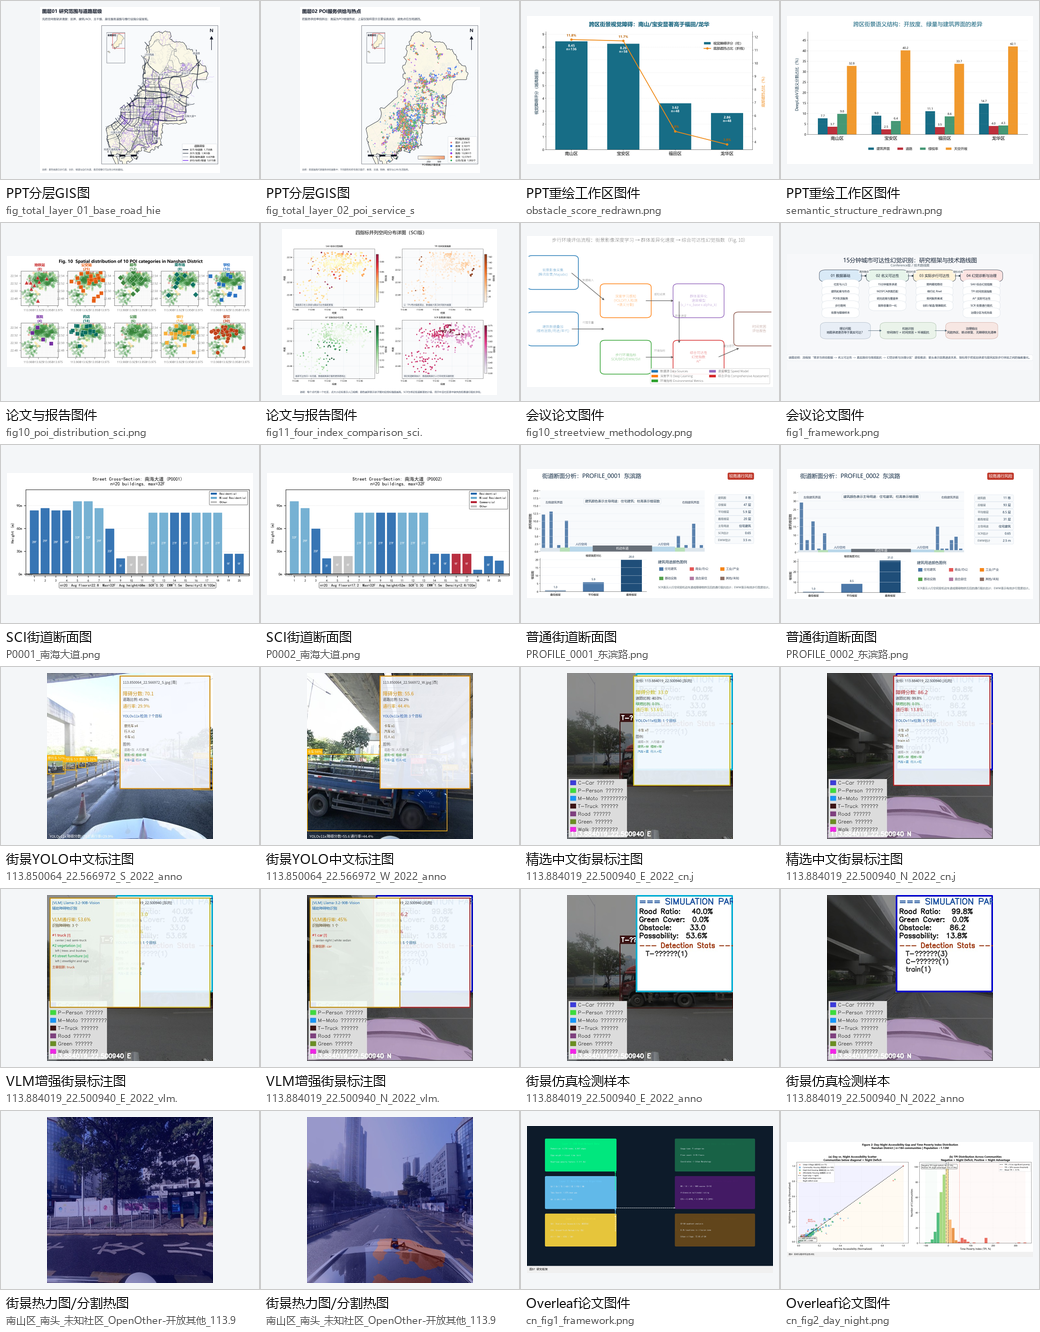

In [3]:
if CONTACT.exists():
    display(Image(filename=str(CONTACT), width=980))
else:
    display(Markdown("未生成 contact sheet。"))


## 3. 各类图像如何产生

下面不是重新造图，而是读取已经生成的溯源 manifest。每一类都对应真实脚本、真实输入数据和重跑命令。


In [4]:
cols = ["category", "image_count", "primary_generating_code", "top_confidence", "example_image"]
display(summary[cols])

for _, row in summary.iterrows():
    cat = row["category"]
    sub = manifest[manifest["category"] == cat].head(6)
    display(Markdown(f"### {cat}"))
    display(sub[[
        "relative_path", "image_role", "generating_code",
        "source_data", "production_method", "rerun_command", "confidence"
    ]])


,category,image_count,primary_generating_code,top_confidence,example_image
0,SCI街道断面图,624,projects/15min-urban-accessibility/v2_real_dat...,directory_match:624,projects/15min-urban-accessibility/v2_real_dat...
1,百度街景采集图,598,projects/15min-urban-accessibility/data/street...,raw_acquired:586; raw_acquired+exact_hit:12,streetview-analysis/baidu_streetview/segmentat...
2,街景YOLO中文标注图,588,streetview-analysis/gpu_scripts/render_only_v2...,directory_match:588,streetview-analysis/annotated_streetview/113.8...
3,街景原始影像,588,projects/15min-urban-accessibility/data/street...,raw_acquired:586; raw_acquired+exact_hit:2,streetview-analysis/raw_streetview/Village/113...
4,街景热力图/分割热图,460,streetview-analysis/scripts/obstacle_analysis....,directory_inferred:420; directory_match:40,streetview-analysis/gpu_scripts/results/heatma...
5,Overleaf附录街景原图,294,streetview-analysis/gpu_scripts/copy_to_append...,directory_match:293; directory_match+exact_hit:1,papers/conference-slides/会议论文/15min可达性幻觉/overl...
6,Overleaf附录街景标注图,294,streetview-analysis/gpu_scripts/copy_to_append...,directory_match:294,papers/conference-slides/会议论文/15min可达性幻觉/overl...
7,报告附录街景原图,294,streetview-analysis/scripts/archive_streetview...,raw_acquired:293; raw_acquired+exact_hit:1,appendix-vlm/appendix_raw/appendix_raw/Village...
8,报告附录街景标注图,294,regenerate_all_annot_final.py (294); regenerat...,directory_match:294,appendix-vlm/appendix_annotated/appendix_annot...
9,普通街道断面图,144,projects/15min-urban-accessibility/v2_real_dat...,directory_match:144,projects/15min-urban-accessibility/v2_real_dat...


### SCI街道断面图

,relative_path,image_role,generating_code,source_data,production_method,rerun_command,confidence
1540,projects/15min-urban-accessibility/v2_real_dat...,楼栋高度/用途/道路断面批量图,projects/15min-urban-accessibility/v2_real_dat...,building_data/南山区-房屋楼栋基础数据_2920004003598.csv; ...,按道路名和建筑坐标滑动窗口分组，依据楼层数估算高度，按建筑用途着色，生成SCI版街道断面图。,python projects/15min-urban-accessibility/v2_r...,directory_match
1541,projects/15min-urban-accessibility/v2_real_dat...,楼栋高度/用途/道路断面批量图,projects/15min-urban-accessibility/v2_real_dat...,building_data/南山区-房屋楼栋基础数据_2920004003598.csv; ...,按道路名和建筑坐标滑动窗口分组，依据楼层数估算高度，按建筑用途着色，生成SCI版街道断面图。,python projects/15min-urban-accessibility/v2_r...,directory_match
1542,projects/15min-urban-accessibility/v2_real_dat...,楼栋高度/用途/道路断面批量图,projects/15min-urban-accessibility/v2_real_dat...,building_data/南山区-房屋楼栋基础数据_2920004003598.csv; ...,按道路名和建筑坐标滑动窗口分组，依据楼层数估算高度，按建筑用途着色，生成SCI版街道断面图。,python projects/15min-urban-accessibility/v2_r...,directory_match
1543,projects/15min-urban-accessibility/v2_real_dat...,楼栋高度/用途/道路断面批量图,projects/15min-urban-accessibility/v2_real_dat...,building_data/南山区-房屋楼栋基础数据_2920004003598.csv; ...,按道路名和建筑坐标滑动窗口分组，依据楼层数估算高度，按建筑用途着色，生成SCI版街道断面图。,python projects/15min-urban-accessibility/v2_r...,directory_match
1544,projects/15min-urban-accessibility/v2_real_dat...,楼栋高度/用途/道路断面批量图,projects/15min-urban-accessibility/v2_real_dat...,building_data/南山区-房屋楼栋基础数据_2920004003598.csv; ...,按道路名和建筑坐标滑动窗口分组，依据楼层数估算高度，按建筑用途着色，生成SCI版街道断面图。,python projects/15min-urban-accessibility/v2_r...,directory_match
1545,projects/15min-urban-accessibility/v2_real_dat...,楼栋高度/用途/道路断面批量图,projects/15min-urban-accessibility/v2_real_dat...,building_data/南山区-房屋楼栋基础数据_2920004003598.csv; ...,按道路名和建筑坐标滑动窗口分组，依据楼层数估算高度，按建筑用途着色，生成SCI版街道断面图。,python projects/15min-urban-accessibility/v2_r...,directory_match


### 百度街景采集图

,relative_path,image_role,generating_code,source_data,production_method,rerun_command,confidence
2458,streetview-analysis/baidu_streetview/segmentat...,街景采集/分割输入或输出,projects/15min-urban-accessibility/data/street...,trajectory_output/trajectory_preview_20m.csv.g...,按照轨迹采样点和方向采集或归档的原始街景，不是绘图脚本生成的统计图。,按采集脚本配置运行；Notebook不自动联网下载。,raw_acquired+exact_hit
2459,streetview-analysis/baidu_streetview/segmentat...,街景采集/分割输入或输出,projects/15min-urban-accessibility/data/street...,trajectory_output/trajectory_preview_20m.csv.g...,按照轨迹采样点和方向采集或归档的原始街景，不是绘图脚本生成的统计图。,按采集脚本配置运行；Notebook不自动联网下载。,raw_acquired+exact_hit
2460,streetview-analysis/baidu_streetview/segmentat...,街景采集/分割输入或输出,projects/15min-urban-accessibility/data/street...,trajectory_output/trajectory_preview_20m.csv.g...,按照轨迹采样点和方向采集或归档的原始街景，不是绘图脚本生成的统计图。,按采集脚本配置运行；Notebook不自动联网下载。,raw_acquired+exact_hit
2461,streetview-analysis/baidu_streetview/segmentat...,街景采集/分割输入或输出,projects/15min-urban-accessibility/data/street...,trajectory_output/trajectory_preview_20m.csv.g...,按照轨迹采样点和方向采集或归档的原始街景，不是绘图脚本生成的统计图。,按采集脚本配置运行；Notebook不自动联网下载。,raw_acquired+exact_hit
2462,streetview-analysis/baidu_streetview/segmentat...,街景采集/分割输入或输出,projects/15min-urban-accessibility/data/street...,trajectory_output/trajectory_preview_20m.csv.g...,按照轨迹采样点和方向采集或归档的原始街景，不是绘图脚本生成的统计图。,按采集脚本配置运行；Notebook不自动联网下载。,raw_acquired+exact_hit
2463,streetview-analysis/baidu_streetview/Village/1...,街景采集/分割输入或输出,projects/15min-urban-accessibility/data/street...,trajectory_output/trajectory_preview_20m.csv.g...,按照轨迹采样点和方向采集或归档的原始街景，不是绘图脚本生成的统计图。,按采集脚本配置运行；Notebook不自动联网下载。,raw_acquired


...

,relative_path,image_role,generating_code,source_data,production_method,rerun_command,confidence
1395,projects/15min-urban-accessibility/v2_real_dat...,街景步行环境与可达性幻觉综合结果,projects/15min-urban-accessibility/section13_f...,streetview segmentation/detection results; sec...,汇总街景步行环境感知、障碍检测和社区可达性幻觉指标，绘制Section13综合结果图。,python projects/15min-urban-accessibility/sect...,directory_match


### 人口夜光栅格图像

,relative_path,image_role,generating_code,source_data,production_method,rerun_command,confidence
1323,projects/15min-urban-accessibility/data/popula...,人口估计或夜间灯光栅格输入,projects/15min-urban-accessibility/scripts/dat...,VIIRS夜间灯光或人口估计数据,人口/夜光栅格输入文件，用于人口估计或空间指标校准，不是matplotlib生成图。,python projects/15min-urban-accessibility/scri...,raw_acquired


### 高德静态地图采集测试图

,relative_path,image_role,generating_code,source_data,production_method,rerun_command,confidence
1324,projects/15min-urban-accessibility/data/street...,高德静态地图API采集/测试输出,projects/15min-urban-accessibility/data/street...,"高德静态地图API; 测试坐标 113.9412,22.5308 或轨迹采样点",调用高德staticmap接口下载PNG静态地图，用于街景/地图采集管线连通性测试。,python projects/15min-urban-accessibility/data...,exact_known


## 4. 逐图查询：输入任意图片路径或类别


In [5]:
def query_image(keyword: str, limit: int = 20):
    mask = manifest.apply(lambda col: col.astype(str).str.contains(keyword, case=False, regex=False)).any(axis=1)
    cols = [
        "relative_path", "category", "image_role", "generating_code",
        "source_data", "production_method", "rerun_command", "confidence", "evidence"
    ]
    return manifest.loc[mask, cols].head(limit)

# 示例1：查询PPT两张重绘图
display(query_image("_ppt_chart_work"))

# 示例2：查询街景中文标注图
display(query_image("annotated_cn", 10))

# 示例3：查询街道断面图
display(query_image("street_profiles_hq", 10))


,relative_path,category,image_role,generating_code,source_data,production_method,rerun_command,confidence,evidence
10,_ppt_chart_work/obstacle_score_redrawn.png,PPT重绘工作区图件,PPT图表替换/原始图备份,redraw_ppt_obstacle_chart.py,脚本内 DISTRICTS/SCORES/COUNTS/BOTTOM_BLOCK 数组,按街景障碍评分、样本量与底部遮挡比例重绘PPT统计图，并替换PPT第33页。,python redraw_ppt_obstacle_chart.py,exact_known+exact_hit,固定输出文件名 obstacle_score_redrawn.png。 | build_im...
11,_ppt_chart_work/semantic_structure_redrawn.png,PPT重绘工作区图件,PPT图表替换/原始图备份,redraw_ppt_semantic_chart.py,streetview-analysis/gpu_scripts/results/seg_re...,按四类街景语义指标聚合矩阵绘制柱状/结构图，并替换PPT第33页对应图表。,python redraw_ppt_semantic_chart.py,exact_known+exact_hit,固定输出文件名 semantic_structure_redrawn.png。 | buil...
12,_ppt_chart_work/slide33_shape14.png,PPT重绘工作区图件,PPT图表替换/原始图备份,redraw_ppt_obstacle_chart.py,哈工大PPT第33页原始shape导出图,PPT第33页障碍评分原始图表截图/导出文件，用作重绘前后对照。,由PPT图表重绘流程导出；通常无需单独重跑。,workspace_artifact,slide33_shape14.png 是第33页原始shape对照图。 | build_i...
13,_ppt_chart_work/slide33_shape14_redrawn_export...,PPT重绘工作区图件,PPT图表替换/原始图备份,redraw_ppt_obstacle_chart.py,NaN,NaN,NaN,exact_script_hit,redraw_ppt_obstacle_chart.py:24 EXPORT_PATH = ...
14,_ppt_chart_work/slide33_shape19.png,PPT重绘工作区图件,PPT图表替换/原始图备份,redraw_ppt_semantic_chart.py,哈工大PPT第33页原始shape导出图,PPT第33页语义结构原始图表截图/导出文件，用作重绘前后对照。,由PPT图表重绘流程导出；通常无需单独重跑。,workspace_artifact,slide33_shape19.png 是第33页原始shape对照图。 | build_i...
15,_ppt_chart_work/slide33_shape19_redrawn_export...,PPT重绘工作区图件,PPT图表替换/原始图备份,redraw_ppt_semantic_chart.py,NaN,NaN,NaN,exact_script_hit,redraw_ppt_semantic_chart.py:26 EXPORT_PATH = ...


,relative_path,category,image_role,generating_code,source_data,production_method,rerun_command,confidence,evidence
2762,streetview-analysis/gpu_scripts/results/annota...,精选中文街景标注图,GPU检测样本二次中文渲染,streetview-analysis/gpu_scripts/rerender_cn.py,gpu_scripts/samples_gpu; gpu_scripts/results/s...,读取GPU下载标注图和仿真JSON，用PIL中文字体重绘右侧中文指标面板。,python streetview-analysis/gpu_scripts/rerende...,directory_match,annotated_cn 输出目录由 rerender_cn.py 配置。
2763,streetview-analysis/gpu_scripts/results/annota...,精选中文街景标注图,GPU检测样本二次中文渲染,streetview-analysis/gpu_scripts/rerender_cn.py,gpu_scripts/samples_gpu; gpu_scripts/results/s...,读取GPU下载标注图和仿真JSON，用PIL中文字体重绘右侧中文指标面板。,python streetview-analysis/gpu_scripts/rerende...,directory_match,annotated_cn 输出目录由 rerender_cn.py 配置。
2764,streetview-analysis/gpu_scripts/results/annota...,精选中文街景标注图,GPU检测样本二次中文渲染,streetview-analysis/gpu_scripts/rerender_cn.py,gpu_scripts/samples_gpu; gpu_scripts/results/s...,读取GPU下载标注图和仿真JSON，用PIL中文字体重绘右侧中文指标面板。,python streetview-analysis/gpu_scripts/rerende...,directory_match,annotated_cn 输出目录由 rerender_cn.py 配置。
2765,streetview-analysis/gpu_scripts/results/annota...,精选中文街景标注图,GPU检测样本二次中文渲染,streetview-analysis/gpu_scripts/rerender_cn.py,gpu_scripts/samples_gpu; gpu_scripts/results/s...,读取GPU下载标注图和仿真JSON，用PIL中文字体重绘右侧中文指标面板。,python streetview-analysis/gpu_scripts/rerende...,directory_match,annotated_cn 输出目录由 rerender_cn.py 配置。
2766,streetview-analysis/gpu_scripts/results/annota...,精选中文街景标注图,GPU检测样本二次中文渲染,streetview-analysis/gpu_scripts/rerender_cn.py,gpu_scripts/samples_gpu; gpu_scripts/results/s...,读取GPU下载标注图和仿真JSON，用PIL中文字体重绘右侧中文指标面板。,python streetview-analysis/gpu_scripts/rerende...,directory_match,annotated_cn 输出目录由 rerender_cn.py 配置。
2767,streetview-analysis/gpu_scripts/results/annota...,精选中文街景标注图,GPU检测样本二次中文渲染,streetview-analysis/gpu_scripts/rerender_cn.py,gpu_scripts/samples_gpu; gpu_scripts/results/s...,读取GPU下载标注图和仿真JSON，用PIL中文字体重绘右侧中文指标面板。,python streetview-analysis/gpu_scripts/rerende...,directory_match,annotated_cn 输出目录由 rerender_cn.py 配置。
2768,streetview-analysis/gpu_scripts/results/annota...,精选中文街景标注图,GPU检测样本二次中文渲染,streetview-analysis/gpu_scripts/rerender_cn.py,gpu_scripts/samples_gpu; gpu_scripts/results/s...,读取GPU下载标注图和仿真JSON，用PIL中文字体重绘右侧中文指标面板。,python streetview-analysis/gpu_scripts/rerende...,directory_match,annotated_cn 输出目录由 rerender_cn.py 配置。
2769,streetview-analysis/gpu_scripts/results/annota...,精选中文街景标注图,GPU检测样本二次中文渲染,streetview-analysis/gpu_scripts/rerender_cn.py,gpu_scripts/samples_gpu; gpu_scripts/results/s...,读取GPU下载标注图和仿真JSON，用PIL中文字体重绘右侧中文指标面板。,python streetview-analysis/gpu_scripts/rerende...,directory_match,annotated_cn 输出目录由 rerender_cn.py 配置。
2770,streetview-analysis/gpu_scripts/results/annota...,精选中文街景标注图,GPU检测样本二次中文渲染,streetview-analysis/gpu_scripts/rerender_cn.py,gpu_scripts/samples_gpu; gpu_scripts/results/s...,读取GPU下载标注图和仿真JSON，用PIL中文字体重绘右侧中文指标面板。,python streetview-analysis/gpu_scripts/rerende...,directory_match,annotated_cn 输出目录由 rerender_cn.py 配置。
2771,streetview-analysis/gpu_scripts/results/annota...,精选中文街景标注图,GPU检测样本二次中文渲染,streetview-analysis/gpu_scripts/rerender_cn.py,gpu_scripts/samples_gpu; gpu_scripts/results/s...,读取GPU下载标注图和仿真JSON，用PIL中文字体重绘右侧中文指标面板。,python streetview-analysis/gpu_scripts/rerende...,directory_match,annotated_cn 输出目录由 rerender_cn.py 配置。


,relative_path,category,image_role,generating_code,source_data,production_method,rerun_command,confidence,evidence
1540,projects/15min-urban-accessibility/v2_real_dat...,SCI街道断面图,楼栋高度/用途/道路断面批量图,projects/15min-urban-accessibility/v2_real_dat...,building_data/南山区-房屋楼栋基础数据_2920004003598.csv; ...,按道路名和建筑坐标滑动窗口分组，依据楼层数估算高度，按建筑用途着色，生成SCI版街道断面图。,python projects/15min-urban-accessibility/v2_r...,directory_match,street_profiles_hq 批量目录由SCI断面图脚本生成。
1541,projects/15min-urban-accessibility/v2_real_dat...,SCI街道断面图,楼栋高度/用途/道路断面批量图,projects/15min-urban-accessibility/v2_real_dat...,building_data/南山区-房屋楼栋基础数据_2920004003598.csv; ...,按道路名和建筑坐标滑动窗口分组，依据楼层数估算高度，按建筑用途着色，生成SCI版街道断面图。,python projects/15min-urban-accessibility/v2_r...,directory_match,street_profiles_hq 批量目录由SCI断面图脚本生成。
1542,projects/15min-urban-accessibility/v2_real_dat...,SCI街道断面图,楼栋高度/用途/道路断面批量图,projects/15min-urban-accessibility/v2_real_dat...,building_data/南山区-房屋楼栋基础数据_2920004003598.csv; ...,按道路名和建筑坐标滑动窗口分组，依据楼层数估算高度，按建筑用途着色，生成SCI版街道断面图。,python projects/15min-urban-accessibility/v2_r...,directory_match,street_profiles_hq 批量目录由SCI断面图脚本生成。
1543,projects/15min-urban-accessibility/v2_real_dat...,SCI街道断面图,楼栋高度/用途/道路断面批量图,projects/15min-urban-accessibility/v2_real_dat...,building_data/南山区-房屋楼栋基础数据_2920004003598.csv; ...,按道路名和建筑坐标滑动窗口分组，依据楼层数估算高度，按建筑用途着色，生成SCI版街道断面图。,python projects/15min-urban-accessibility/v2_r...,directory_match,street_profiles_hq 批量目录由SCI断面图脚本生成。
1544,projects/15min-urban-accessibility/v2_real_dat...,SCI街道断面图,楼栋高度/用途/道路断面批量图,projects/15min-urban-accessibility/v2_real_dat...,building_data/南山区-房屋楼栋基础数据_2920004003598.csv; ...,按道路名和建筑坐标滑动窗口分组，依据楼层数估算高度，按建筑用途着色，生成SCI版街道断面图。,python projects/15min-urban-accessibility/v2_r...,directory_match,street_profiles_hq 批量目录由SCI断面图脚本生成。
1545,projects/15min-urban-accessibility/v2_real_dat...,SCI街道断面图,楼栋高度/用途/道路断面批量图,projects/15min-urban-accessibility/v2_real_dat...,building_data/南山区-房屋楼栋基础数据_2920004003598.csv; ...,按道路名和建筑坐标滑动窗口分组，依据楼层数估算高度，按建筑用途着色，生成SCI版街道断面图。,python projects/15min-urban-accessibility/v2_r...,directory_match,street_profiles_hq 批量目录由SCI断面图脚本生成。
1546,projects/15min-urban-accessibility/v2_real_dat...,SCI街道断面图,楼栋高度/用途/道路断面批量图,projects/15min-urban-accessibility/v2_real_dat...,building_data/南山区-房屋楼栋基础数据_2920004003598.csv; ...,按道路名和建筑坐标滑动窗口分组，依据楼层数估算高度，按建筑用途着色，生成SCI版街道断面图。,python projects/15min-urban-accessibility/v2_r...,directory_match,street_profiles_hq 批量目录由SCI断面图脚本生成。
1547,projects/15min-urban-accessibility/v2_real_dat...,SCI街道断面图,楼栋高度/用途/道路断面批量图,projects/15min-urban-accessibility/v2_real_dat...,building_data/南山区-房屋楼栋基础数据_2920004003598.csv; ...,按道路名和建筑坐标滑动窗口分组，依据楼层数估算高度，按建筑用途着色，生成SCI版街道断面图。,python projects/15min-urban-accessibility/v2_r...,directory_match,street_profiles_hq 批量目录由SCI断面图脚本生成。
1548,projects/15min-urban-accessibility/v2_real_dat...,SCI街道断面图,楼栋高度/用途/道路断面批量图,projects/15min-urban-accessibility/v2_real_dat...,building_data/南山区-房屋楼栋基础数据_2920004003598.csv; ...,按道路名和建筑坐标滑动窗口分组，依据楼层数估算高度，按建筑用途着色，生成SCI版街道断面图。,python projects/15min-urban-accessibility/v2_r...,directory_match,street_profiles_hq 批量目录由SCI断面图脚本生成。
1549,projects/15min-urban-accessibility/v2_real_dat...,SCI街道断面图,楼栋高度/用途/道路断面批量图,projects/15min-urban-accessibility/v2_real_dat...,building_data/南山区-房屋楼栋基础数据_2920004003598.csv; ...,按道路名和建筑坐标滑动窗口分组，依据楼层数估算高度，按建筑用途着色，生成SCI版街道断面图。,python projects/15min-urban-accessibility/v2_r...,directory_match,street_profiles_hq 批量目录由SCI断面图脚本生成。


## 5. 脚本精确命中证据


In [6]:
if len(hits):
    display(hits.head(80))
    display(
        hits.groupby(["script", "hit_kind"])
        .size()
        .rename("hit_count")
        .reset_index()
        .sort_values("hit_count", ascending=False)
        .head(40)
    )
else:
    display(Markdown("没有脚本命中记录。"))


,image,script,line_no,hit_kind,snippet
0,15分钟城市时间贫困研究/conference_paper/figures/fig10_st...,build_report_with_appendix.py,369,insertion,"add_fig(doc, P('15分钟城市时间贫困研究','conference_pape..."
1,15分钟城市时间贫困研究/conference_paper/figures/fig10_st...,build_report_with_appendix.py,550,insertion,"('fig10_streetview_methodology.png', '图A1-10 街..."
2,15分钟城市时间贫困研究/conference_paper/figures/fig10_st...,embed_figures.py,23,insertion,"'（表1：多源数据汇总表）': os.path.join(BASE, 'projects',..."
3,15分钟城市时间贫困研究/conference_paper/figures/fig10_st...,projects/15min-urban-accessibility/conference_...,1010,generation_or_copy,"save_fig(fig, 'fig10_streetview_methodology.png')"
4,15分钟城市时间贫困研究/conference_paper/figures/fig1_fra...,build_final_report.py,272,reference,"img_path=os.path.join(BASE, '15分钟城市时间贫困研究', 'c..."
...,...,...,...,...,...
75,15分钟城市时间贫困研究/conference_paper/figures/fig5_typ...,projects/15min-urban-accessibility/conference_...,617,generation_or_copy,"save_fig(fig, 'fig5_type_analysis.png')"
76,15分钟城市时间贫困研究/conference_paper/figures/fig6_dep...,build_final_report.py,587,reference,"img_path=os.path.join(BASE, '15分钟城市时间贫困研究', 'c..."
77,15分钟城市时间贫困研究/conference_paper/figures/fig6_dep...,build_report_with_appendix.py,436,insertion,"add_fig(doc, P('15分钟城市时间贫困研究','conference_pape..."
78,15分钟城市时间贫困研究/conference_paper/figures/fig6_dep...,build_report_with_appendix.py,546,insertion,"('fig6_deprived_communities.png', '图A1-6 弱势群体剥..."


,script,hit_kind,hit_count
3,build_report_with_appendix.py,insertion,104
4,embed_figures.py,insertion,55
60,redraw_report_figures.py,generation_or_copy,53
5,embed_figures2.py,insertion,52
6,embed_figures3.py,insertion,40
8,embed_figures5.py,insertion,40
9,embed_figures6.py,insertion,40
10,embed_figures7.py,insertion,40
7,embed_figures4.py,insertion,40
66,streetview-analysis/gpu_scripts/copy_figures.py,generation_or_copy,28


## 6. 关键生成链路

### 6.1 GIS路线图 / 分层总图

`redraw_total_gis_map.py` 负责综合总图；`redraw_total_gis_map_layers.py` 读取同一批边界、路网、建筑、POI、社区、route和trajectory数据，输出第15-20页使用的分层图。  
`revise_layered_map_ppt_style.py` 只负责把这些图和诊断文字插入PPT。

### 6.2 指标空间对比与报告图

报告中的指标分布、SAII、昼夜可达性、POI分布等图主要来自 `paper/generate_figures.py`、`redraw_report_figures.py`、`v2_real_data/scripts/p2_accessibility/*.py`。  
具体哪张图命中了哪个脚本，以 manifest 的 `generating_code` 和 `evidence` 为准。

### 6.3 街道断面图

`generate_street_profiles.py` 和 `generate_street_profiles_sci.py` 从楼栋基础数据读取中心坐标、层数、使用用途，按道路名/空间窗口分组，绘制建筑高度和用途颜色。  
`profile_summary.csv` 是这些断面图的统计索引。

### 6.4 街景原图、标注图、热力图

原始街景属于采集/下载影像，不是统计图生成；标注图来自 YOLO/语义分割/VLM 后处理；热力图来自FCN/YOLO遮挡或语义分割结果。  
Notebook 不执行远程推理，只记录对应脚本和数据。


## 7. 安全重跑命令清单


In [7]:
rerun_table = (
    manifest[["category", "generating_code", "source_data", "rerun_command", "confidence"]]
    .drop_duplicates()
    .sort_values(["category", "generating_code"])
)
display(rerun_table)

display(Markdown(
    "**注意：** `redraw_ppt_*`、`revise_layered_map_ppt_style.py`、`redraw_report_figures.py` 会修改PPT或DOCX；"
    "远程GPU/API脚本可能含服务器或API依赖。需要重跑时应先备份并确认环境。"
))


,category,generating_code,source_data,rerun_command,confidence
3028,GPU下载标注样本,streetview-analysis/gpu_scripts/download_sampl...,远程GPU街景检测可视化结果；gpu_scripts/results/all_results...,python streetview-analysis/gpu_scripts/downloa...,directory_match
3029,GPU下载标注样本,streetview-analysis/gpu_scripts/download_sampl...,远程GPU街景检测可视化结果；gpu_scripts/results/all_results...,python streetview-analysis/gpu_scripts/downloa...,directory_match+exact_hit
1325,Notebook输出图,build_implementation_notebook.py; build_image_...,Notebook读取的指标表、manifest与代表图样本,python build_image_provenance_notebook.py,notebook_output
1210,Overleaf论文图件,projects/15min-urban-accessibility/conference_...,conference_paper/figures; gpu_scripts/results/...,python projects/15min-urban-accessibility/conf...,directory_inferred
1221,Overleaf论文图件,projects/15min-urban-accessibility/conference_...,conference_paper/figures; gpu_scripts/results/...,python projects/15min-urban-accessibility/conf...,directory_inferred+exact_hit
...,...,...,...,...,...
1342,论文与报告图件,projects/15min-urban-accessibility/paper/gener...,accessibility_results.csv; section13_community...,按 manifest exact_hit 脚本运行；报告替换脚本默认不自动执行。,directory_inferred+exact_hit
1352,论文与报告图件,projects/15min-urban-accessibility/paper/gener...,accessibility_results.csv; section13_community...,按 manifest exact_hit 脚本运行；报告替换脚本默认不自动执行。,directory_inferred+exact_hit
1340,论文与报告图件,projects/15min-urban-accessibility/paper/gener...,accessibility_results.csv; section13_community...,按 manifest exact_hit 脚本运行；报告替换脚本默认不自动执行。,directory_inferred+exact_hit
1358,论文与报告图件,redraw_total_gis_map.py,南山区边界SHP、nanshan_road_network.shp、building_dat...,python redraw_total_gis_map.py,exact_known+exact_hit


**注意：** `redraw_ppt_*`、`revise_layered_map_ppt_style.py`、`redraw_report_figures.py` 会修改PPT或DOCX；远程GPU/API脚本可能含服务器或API依赖。需要重跑时应先备份并确认环境。

## 8. 导出文件


In [8]:
exports = pd.DataFrame([
    {"文件": str(MANIFEST.relative_to(ROOT)), "用途": "逐图完整溯源CSV，Excel可打开"},
    {"文件": str((OUT / "image_provenance_manifest.json").relative_to(ROOT)), "用途": "逐图结构化JSON"},
    {"文件": str((OUT / "image_provenance_manifest.md").relative_to(ROOT)), "用途": "Markdown版逐图清单"},
    {"文件": str(SUMMARY.relative_to(ROOT)), "用途": "按类别汇总"},
    {"文件": str(HITS.relative_to(ROOT)), "用途": "脚本命中证据"},
    {"文件": str(CONTACT.relative_to(ROOT)), "用途": "代表性图像预览拼图"},
])
display(exports)


,文件,用途
0,projects\15min-urban-accessibility\notebook_ou...,逐图完整溯源CSV，Excel可打开
1,projects\15min-urban-accessibility\notebook_ou...,逐图结构化JSON
2,projects\15min-urban-accessibility\notebook_ou...,Markdown版逐图清单
3,projects\15min-urban-accessibility\notebook_ou...,按类别汇总
4,projects\15min-urban-accessibility\notebook_ou...,脚本命中证据
5,projects\15min-urban-accessibility\notebook_ou...,代表性图像预览拼图
